In [1]:
#Incarcare fisiere
import pandas as pd
import matplotlib.pyplot as plt
products = pd.read_csv('products_aw.csv')
transactions = pd.read_csv('transactions_aw.csv')

In [2]:
# Operatie inspectie 
products.shape

(504, 18)

In [3]:
# Operatie inspectie 
transactions.shape

(113443, 6)

In [4]:
# Operatie inspectie 
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          504 non-null    int64  
 1   Name               504 non-null    str    
 2   ProductNumber      504 non-null    str    
 3   MakeFlag           504 non-null    int64  
 4   FinishedGoodsFlag  504 non-null    int64  
 5   Color              256 non-null    str    
 6   StandardCost       504 non-null    float64
 7   ListPrice          504 non-null    float64
 8   Size               211 non-null    str    
 9   Weight             205 non-null    float64
 10  DaysToManufacture  504 non-null    int64  
 11  ProductLine        278 non-null    str    
 12  Class              247 non-null    str    
 13  Style              211 non-null    str    
 14  SellStartDate      504 non-null    str    
 15  SellEndDate        98 non-null     float64
 16  Subcategory        295 non-null    st

In [5]:
# Operatie inspectie 
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 113443 entries, 0 to 113442
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    113443 non-null  int64  
 1   ProductID        113443 non-null  int64  
 2   TransactionDate  113443 non-null  str    
 3   TransactionType  113443 non-null  str    
 4   Quantity         113443 non-null  int64  
 5   ActualCost       113443 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 5.2 MB


In [6]:
# Operatie inspectie 
products.head(5)

,ProductID,Name,ProductNumber,MakeFlag,FinishedGoodsFlag,Color,StandardCost,ListPrice,Size,Weight,DaysToManufacture,ProductLine,Class,Style,SellStartDate,SellEndDate,Subcategory,Category
0,1,Adjustable Race,AR-5381,0,0,NaN,0.0,0.0,NaN,NaN,0,NaN,NaN,NaN,2008-04-30,NaN,NaN,NaN
1,2,Bearing Ball,BA-8327,0,0,NaN,0.0,0.0,NaN,NaN,0,NaN,NaN,NaN,2008-04-30,NaN,NaN,NaN
2,3,BB Ball Bearing,BE-2349,1,0,NaN,0.0,0.0,NaN,NaN,1,NaN,NaN,NaN,2008-04-30,NaN,NaN,NaN
3,4,Headset Ball Bearings,BE-2908,0,0,NaN,0.0,0.0,NaN,NaN,0,NaN,NaN,NaN,2008-04-30,NaN,NaN,NaN
4,316,Blade,BL-2036,1,0,NaN,0.0,0.0,NaN,NaN,1,NaN,NaN,NaN,2008-04-30,NaN,NaN,NaN


In [7]:
# Operatie inspectie 
transactions.head(5)

,TransactionID,ProductID,TransactionDate,TransactionType,Quantity,ActualCost
0,100000,784,2013-07-31,W,2,0.0
1,100001,794,2013-07-31,W,1,0.0
2,100002,797,2013-07-31,W,1,0.0
3,100003,798,2013-07-31,W,1,0.0
4,100004,799,2013-07-31,W,1,0.0



Acest notebook este dedicat analizării datelor operaționale și comerciale ale companiei, având ca scop extragerea de insight-uri cheie privind profitabilitatea structurii de produse și sezonalitatea fluxurilor logistice.

1. Conținutul Seturilor de Date

Pentru realizarea acestui studiu, utilizăm două fișiere de bază în format CSV:

* **`products_aw.csv` (Catalogul de Produse):** Conține informații structurate despre portofoliul de articole al companiei. Printre variabilele critice analizate se numără identificatorul unic (`ProductID`), denumirea (`Name`), flag-ul de produs finit (`FinishedGoodsFlag`), linia de producție/categoria (`ProductLine`), prețul de listă stabilit pentru piață (`ListPrice`) și costul standard de producție (`StandardCost`).
* **`transactions.csv` (Registrul de Tranzacții):** Cuprinde istoricul complet al mișcărilor de stoc și al vânzărilor. Fișierul stochează date esențiale precum ID-ul tranzacției, identificatorul produsului (`ProductID`), data exactă a operațiunii (`TransactionDate`) și tipul tranzacției (`TransactionType`), clasificat în trei categorii majore: *Sales* (S), *Purchase* (P) și *Work Order* (W).


## 2. Obiectivele și Direcțiile de Analiză

Studiul este structurat în patru parti principalale de analiză statistică și vizuală, urmărind rezolvarea următoarelor cerințe de business:

1. Structura Prețurilor** | Izolarea produselor active și măsurarea diversității gamelor de produse. | Preț Median & Deviația Standard | *Scatter Plot cu Error Bars* (Linii de împrăștiere) |
2. Profitabilitate (Marjă)** | Calculul marjei brute și identificarea produselor de risc (cu marjă sub 10%). | Marja Brută (%) & Media pe categorii | *Bar Chart* (Grafic cu bare verticale și etichete) |
3. Fluxuri Operaționale** | Segmentarea volumului de tranzacții și detectarea celor top 10 produse „vedetă”. | Volume Absolute & Ponderi Procentuale (%) | *Donut Chart* (Grafic gogoașă pentru procente) |
4. Sezonalitate (Timp)** | Maparea comportamentului tranzacțional pe luni și depistarea zilei de vârf din săptămână. | Extragere `.dt.month` și `.dt.dayofweek` | *Line Plot* (Grafic de evoluție cu Data Labels) |

In [8]:
#Identificarea valorilor lipsa - adunarea valorilor lipsa 
products.isna().sum()

ProductID              0
Name                   0
ProductNumber          0
MakeFlag               0
FinishedGoodsFlag      0
Color                248
StandardCost           0
ListPrice              0
Size                 293
Weight               299
DaysToManufacture      0
ProductLine          226
Class                257
Style                293
SellStartDate          0
SellEndDate          406
Subcategory          209
Category             209
dtype: int64

In [9]:
# Pasul 1: Eliminăm spațiile de tip trailing și leading pentru Products
products['ProductLine'] = products['ProductLine'].str.strip()

# Pasul 2: Definim un dicționar cu regulile de înlocuire (Mapping)
coduri_noi = {
    'R': 'Road',
    'M': 'Mountain',
    'S': 'Standard',
    'T': 'Touring'
}

# Pasul 3: Înlocuim literele cu denumirile complete
products['ProductLine'] = products['ProductLine'].replace(coduri_noi)

# Pasul 4: Verificăm dacă a funcționat corect
print("Valori unice rămase în ProductLine:")
print(products['ProductLine'].unique())

Valori unice rămase în ProductLine:
<StringArray>
[nan, 'Road', 'Standard', 'Mountain', 'Touring']
Length: 5, dtype: str


In [10]:
# Eliminăm spațiile trailing pentru Class
products['Class'] = products['Class'].str.strip()

# Dicționarul pentru Class
coduri_class = {
    'H': 'High',
    'M': 'Medium',
    'L': 'Low'
}

# Înlocuim codurile
products['Class'] = products['Class'].replace(coduri_class)

# Verificăm rezultatul
print("Valori unice în Class:", products['Class'].unique())

Valori unice în Class: <StringArray>
[nan, 'Low', 'Medium', 'High']
Length: 4, dtype: str


In [11]:
#Schimbare tip data 

transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])

In [12]:
# Verificare tip data
print(transactions['TransactionDate'].dtypes)

datetime64[us]


In [13]:
#Afisare primele 3 randuri 

display(transactions[['TransactionDate']].head(3))

,TransactionDate
0,2013-07-31
1,2013-07-31
2,2013-07-31


De ce Actual Cost = 0 pentru tipul W

In baza de data AdventureWorks, in cazul tranzactiilor, litera "W" vine de la work in progress/process

In [14]:
# Ticket PE01 — Catalogul Produselor

# Filtreaza doar produsele finite cu pret valid: FinishedGoodsFlag = 1 si ListPrice > 0
# Creaza cel putin o functie def

In [15]:
#Creare functie si filtrare 

def E01_filtrareProduseValide(df):
    df_filtrat = df[(df['FinishedGoodsFlag'] == 1) & (df['ListPrice'] > 0)]
    return df_filtrat

In [16]:
#Creare functie si categorie 

def E01_Categorie(df):
    statistici = df.groupby('ProductLine').agg(
        NumarProduse=('ListPrice', 'count'),
        PretMedian=('ListPrice', 'median'),
        DiversitatePreturi=('ListPrice', 'std') # Deviația standard măsoară diversitatea/împrăștierea prețurilor
    ).reset_index()
    
    return statistici

In [17]:
#Aplicam functia de filtrare

products_valide = E01_filtrareProduseValide(products)

In [18]:
#Statistici pe baza filtrarii

raport_categorii = E01_Categorie(products_valide)
print("RAPORT STATISTIC PER CATEGORIE")
display(raport_categorii)

RAPORT STATISTIC PER CATEGORIE


,ProductLine,NumarProduse,PretMedian,DiversitatePreturi
0,Mountain,91,364.09,1011.480642
1,Road,100,688.91,918.234983
2,Standard,35,53.99,26.847068
3,Touring,52,742.35,759.887063


In [19]:
#Identificam categoria cu cea mai mare diversitate 

idx_max_diversitate = raport_categorii['DiversitatePreturi'].idxmax()

#Idmax se uita pe coloana DiversitatePreturi, cauta cel mai mare numar si returneaza numarul randului

categorie_max_div = raport_categorii.loc[idx_max_diversitate, 'ProductLine']
#Iloc cauta randul si coloana din ProductLine

valoare_max_div = raport_categorii.loc[idx_max_diversitate, 'DiversitatePreturi']

print(f"\nCategoria cu cea mai mare diversitate de prețuri este: {categorie_max_div} (Deviația standard: {valoare_max_div:.2f})")


Categoria cu cea mai mare diversitate de prețuri este: Mountain (Deviația standard: 1011.48)


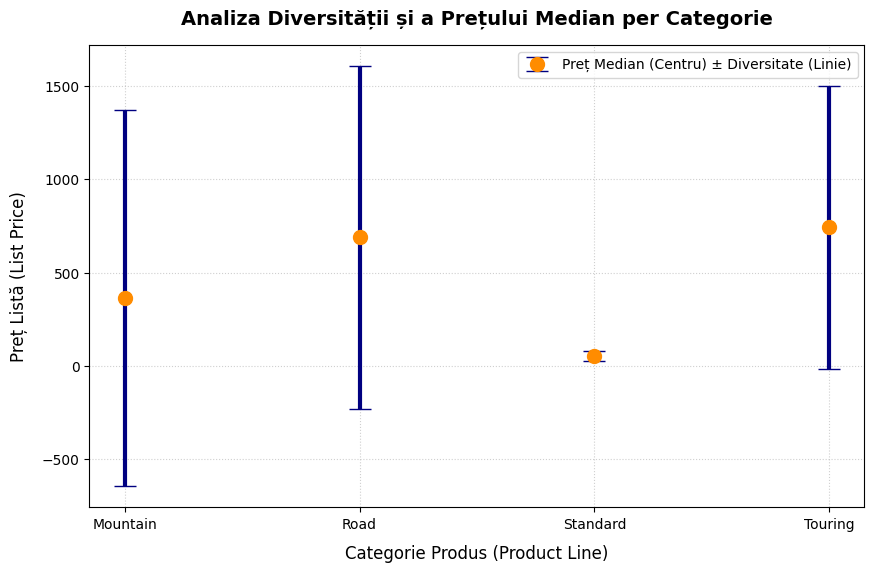

In [20]:
#Creare grafic 

plt.figure(figsize=(10, 6))

categorii = raport_categorii['ProductLine'].astype(str)
mediene = raport_categorii['PretMedian']
diversitate = raport_categorii['DiversitatePreturi'].fillna(0)


plt.errorbar(x=categorii, y=mediene, yerr=diversitate, 
             fmt='o',          # 'o' înseamnă că marcatorul va fi un cerc mare
             markersize=10,     # Dimensiunea punctului de mediană
             color='darkorange',# Culoarea punctului central
             ecolor='navy',     # Culoarea liniilor de diversitate
             elinewidth=3,      # Grosimea liniilor de diversitate
             capsize=8,         # Lățimea liniilor capăt (mustățile)
             label='Preț Median (Centru) ± Diversitate (Linie)')


plt.title('Analiza Diversității și a Prețului Median per Categorie', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categorie Produs (Product Line)', fontsize=12, labelpad=10)
plt.ylabel('Preț Listă (List Price)', fontsize=12, labelpad=10)


plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.show()

În urma analizării graficului, se observă că produsele din categoria **Mountain** prezintă cea mai mare diversitate de prețuri, având cea mai întinsă linie verticală (cea mai mare deviație standard). La polul opus, produsele din categoria **Standard** sunt extrem de omogene, linia scurtă indicând prețuri foarte grupate și o lipsă de variabilitate în gamă. Punctele portocalii evidențiază clar că segmentele **Road** și **Touring** au cele mai ridicate prețuri mediane, oferind o perspectivă rapidă asupra poziționării comerciale a fiecărei categorii

In [21]:
#Ticket PE02 — Pret si Cost

#Cerinte tehnice
#Lucreaza cu produsele finite cu ListPrice > 0 si StandardCost > 0
#Marja bruta (%) = (ListPrice - StandardCost) / ListPrice * 100
#Creaza cel putin o functie def pentru calculul marjei

In [22]:
#Creare functie 

def E02_MarjaBruta(df):
    #aplicare filtru
    df_filtrat = df[(df['ListPrice'] > 0) & (df['StandardCost'] > 0)].copy()

    #aplicare formula
    df_filtrat['MarjaBruta_Procent'] = ((df_filtrat['ListPrice'] - df_filtrat['StandardCost']) / df_filtrat['ListPrice']) * 100

    return df_filtrat

In [23]:
#aplicare functie creata pe tabelul nostru 
products_marja = E02_MarjaBruta(products)

In [24]:
print(" MARJA BRUTĂ MEDIE PER CATEGORIE ")

# Grupăm după categorie (ProductLine) și calculăm media marjei brute
marja_medie_cat = products_marja.groupby('ProductLine')['MarjaBruta_Procent'].mean().reset_index()

# Rotunjim la 2 zecimale 
marja_medie_cat['MarjaBruta_Procent'] = marja_medie_cat['MarjaBruta_Procent'].round(2)
display(marja_medie_cat)

 MARJA BRUTĂ MEDIE PER CATEGORIE 


,ProductLine,MarjaBruta_Procent
0,Mountain,49.95
1,Road,43.18
2,Standard,51.10
3,Touring,43.04


In [25]:
print("\n PRODUSE CU MARJĂ SUB 10% ")

# Filtrăm produsele care au marja strict mai mică de 10%
produse_marja_mica = products_marja[products_marja['MarjaBruta_Procent'] < 10]

numar_produse_problema = len(produse_marja_mica)

if numar_produse_problema > 0:
    print(f"Da, există {numar_produse_problema} produse cu marja sub 10%.")
    print("\nDistribuția acestor produse pe categorii:")
    
    # Numărăm câte produse cu marjă mică sunt în fiecare categorie
    distributie_categorii = produse_marja_mica['ProductLine'].value_counts().reset_index()
    distributie_categorii.columns = ['ProductLine', 'NumarProduse']
    display(distributie_categorii)
    
else:
    print("Nu există produse cu marja sub 10%. Toate produsele au o profitabilitate acceptabilă.")


 PRODUSE CU MARJĂ SUB 10% 
Nu există produse cu marja sub 10%. Toate produsele au o profitabilitate acceptabilă.


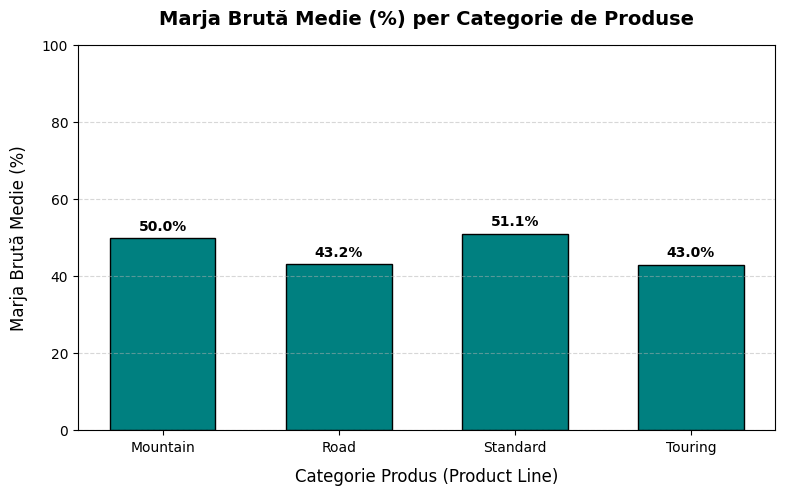

In [26]:
#creare grafic 

plt.figure(figsize=(9, 5))

plt.bar(marja_medie_cat['ProductLine'].astype(str), marja_medie_cat['MarjaBruta_Procent'], 
        color='teal', edgecolor='darkgrid' if 'darkgrid' in plt.style.available else 'black', width=0.6)

# Titlu si etichete 
plt.title('Marja Brută Medie (%) per Categorie de Produse', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categorie Produs (Product Line)', fontsize=12, labelpad=10)
plt.ylabel('Marja Brută Medie (%)', fontsize=12, labelpad=10)
plt.ylim(0, 100) # Axa de la 0 la 100% pentru o perspectiva corecta
plt.grid(axis='y', linestyle='--', alpha=0.5)

# afisarea valorilor desupra fiecarei bare
for i, v in enumerate(marja_medie_cat['MarjaBruta_Procent']):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()

În urma analizării graficului, se observă că profitabilitatea este excelentă pe toate segmentele, marja brută medie menținându-se la un nivel foarte ridicat, între 43% și 51.1%. De asemenea, datele confirmă că nu avem niciun produs critic cu o marjă de profit sub pragul de 10%, toate modelele fiind sigure din punct de vedere financiar. Categoria **Standard** înregistrează cea mai mare performanță cu o marjă medie de 51.1%, oferind managementului certitudinea că structura actuală de prețuri este extrem de eficientă în raport cu costurile de producție.

In [27]:
#Ticket PE03 — Analiza Tranzactiilor

#Cerinte tehnice
#Creaza cel putin o functie def
#Raportul trebuie sa raspunda la
#Cate tranzactii avem per tip (S, P, W) si ce procent reprezinta fiecare?
#Care sunt top 10 produse dupa numarul de tranzactii de tip S?

In [28]:
#creare functie 

def E03_analizaTranzactii(df_tranzactii):
    total_tranzactii = len(df_tranzactii)

    #calcul volum si procent 
    raport_tipuri = df_tranzactii['TransactionType'].value_counts().reset_index()
    raport_tipuri.columns = ['TransactionType', 'NumarTranzactii']
    raport_tipuri['Procent'] = (raport_tipuri['NumarTranzactii'] / total_tranzactii) * 100
    raport_tipuri['Procent'] = raport_tipuri['Procent'].round(2)

    #filtram top10 dupa transactie tip "S"
    tranzactii_S = df_tranzactii[df_tranzactii['TransactionType'] == 'S']
    top10_produse = tranzactii_S['ProductID'].value_counts().head(10).reset_index()
    top10_produse.columns = ['ProductID', 'NumarTranzactii_S']
    
    return raport_tipuri, top10_produse

In [29]:
#aplicare functie

raport_tipuri, top10_produse_S = E03_analizaTranzactii(transactions)

print("DISTRIBUȚIA TRANZACȚIILOR PER TIP")
display(raport_tipuri)

print("\n. TOP 10 PRODUSE DUPĂ TRANZACȚII DE TIP 'S'")
display(top10_produse_S)

DISTRIBUȚIA TRANZACȚIILOR PER TIP


,TransactionType,NumarTranzactii,Procent
0,S,74575,65.74
1,W,31002,27.33
2,P,7866,6.93



. TOP 10 PRODUSE DUPĂ TRANZACȚII DE TIP 'S'


,ProductID,NumarTranzactii_S
0,870,4187
1,873,3003
2,921,2814
3,712,2348
4,707,2278
5,711,2220
6,708,2192
7,922,2149
8,878,1918
9,871,1832


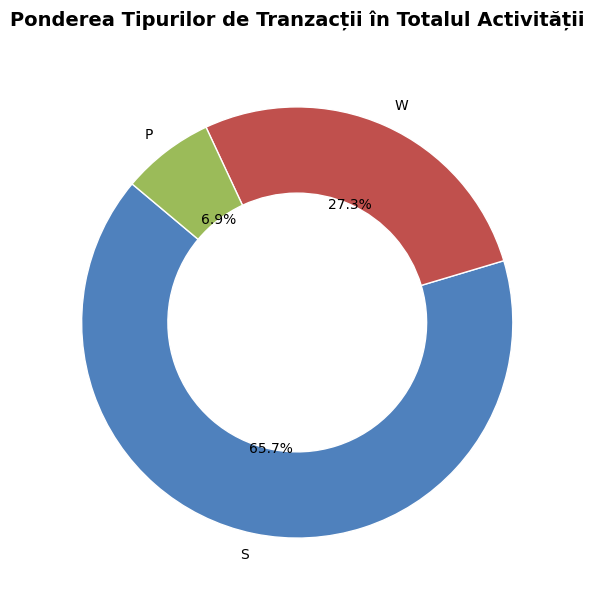

In [30]:
# creare grafic 

plt.figure(figsize=(7, 7))

# pie chart pentru a vedea proportia 
plt.pie(raport_tipuri['NumarTranzactii'], 
        labels=raport_tipuri['TransactionType'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#4f81bd', '#c0504d', '#9bbb59'],
        wedgeprops=dict(width=0.4, edgecolor='w')) # Stil 'Donut chart' (gogoașă)

# titlu 
plt.title('Ponderea Tipurilor de Tranzacții în Totalul Activității', fontsize=14, fontweight='bold', pad=20)

plt.show()

În urma analizării graficului, se observă că tranzacțiile de tip **S** domină activitatea companiei, reprezentând o pondere majoritară de **65.7%** din totalul operațiunilor. Acestea sunt urmate de tranzacțiile de tip **W** cu **27.3%**, în timp ce tipul **P** înregistrează cea mai mică prezență, de doar **6.9%**. Această distribuție indică un volum intens pe zona de vânzări (S) și mișcări de stoc (W), completat de lista celor mai rulate 10 produse individuale care susțin acest nucleu operațional.

In [31]:
#Ticket PE04 — Evolutie in Timp

#Cerinte tehnice
# Extrage luna (.dt.month) si ziua saptamanii (.dt.dayofweek) din TransactionDate
#Zilele saptamanii sa fie afisate cu denumire (Luni, Marti...), nu ca numere
#Creaza cel putin o functie def
#Raportul trebuie sa raspunda la
#Cum a evoluat numarul de tranzactii pe luni? Care luna a fost cea mai activa?
#In ce zi a saptamanii se inregistreaza cele mai multe tranzactii?

In [32]:
#creare functie 

def E04_procesareDateTranzactii(df_tranzactii):
  
    df_copie = df_tranzactii.copy()
    
    # Coloana este de tip datetime
    df_copie['TransactionDate'] = pd.to_datetime(df_copie['TransactionDate'])
    
    #Extragem luna 
    df_copie['Luna_Numar'] = df_copie['TransactionDate'].dt.month
    
    # Extragem ziua
    df_copie['Zi_Numar'] = df_copie['TransactionDate'].dt.dayofweek
    
    # Lista pt maparea zilelor
    nume_zile = {
        0: 'Luni',
        1: 'Marti',
        2: 'Miercuri',
        3: 'Joi',
        4: 'Vineri',
        5: 'Sambata',
        6: 'Duminica'
    }
    
    # Inlocuirea numerelelor cu denumirile text
    df_copie['Zi_Saptamana'] = df_copie['Zi_Numar'].map(nume_zile)
    
    return df_copie

In [33]:
#Aplicam functia pe tabelul nostry
transactions_procesat = E04_procesareDateTranzactii(transactions)

print("EVOLUȚIA TRANZACȚIILOR PE LUNI")
# grupăm dupa numarul lunii pentru a pastra ordinea cronologica corecta
evolutie_luni = transactions_procesat.groupby('Luna_Numar').size().reset_index(name='NumarTranzactii')

# adaugam nume lunilor pentru tabelul afișat
nume_luni = {1:'Ian', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mai', 6:'Iun', 7:'Iul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Noi', 12:'Dec'}
evolutie_luni['Luna'] = evolutie_luni['Luna_Numar'].map(nume_luni)
display(evolutie_luni[['Luna', 'NumarTranzactii']])



EVOLUȚIA TRANZACȚIILOR PE LUNI


,Luna,NumarTranzactii
0,Ian,10788
1,Feb,7749
2,Mar,13853
3,Apr,9295
4,Mai,12779
5,Iun,3186
6,Iul,4848
7,Aug,9576
8,Sep,10199
9,Oct,10638


In [34]:
# identificam cea mai activa luna
luna_activa_idx = evolutie_luni['NumarTranzactii'].idxmax()
luna_activa_nume = evolutie_luni.loc[luna_activa_idx, 'Luna']
luna_activa_val = evolutie_luni.loc[luna_activa_idx, 'NumarTranzactii']
print(f"Cea mai activă lună a fost: {luna_activa_nume} ({luna_activa_val} tranzacții)\n")

print("TRANZACȚII PER ZI A SAPTAMANII")
# grupam după denumirea zilei, dar sortam după ordinea logica a zilelor (0-6)
tranzactii_zile = transactions_procesat.groupby(['Zi_Numar', 'Zi_Saptamana']).size().reset_index(name='NumarTranzactii')
display(tranzactii_zile[['Zi_Saptamana', 'NumarTranzactii']])

Cea mai activă lună a fost: Mar (13853 tranzacții)

TRANZACȚII PER ZI A SAPTAMANII


,Zi_Saptamana,NumarTranzactii
0,Luni,19052
1,Marti,14568
2,Miercuri,22025
3,Joi,16124
4,Vineri,14515
5,Sambata,15098
6,Duminica,12061


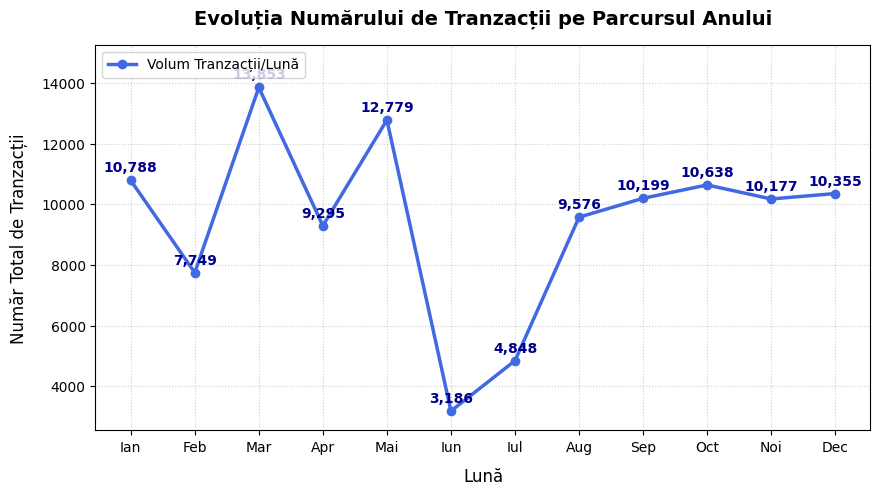

In [35]:
#crearea grafic 

plt.figure(figsize=(10, 5))

plt.plot(evolutie_luni['Luna'], evolutie_luni['NumarTranzactii'], 
         marker='o', color='royalblue', linewidth=2.5, label='Volum Tranzacții/Lună')

for i, v in enumerate(evolutie_luni['NumarTranzactii']):
    plt.text(x=i,                    # Poziția pe axa X (indexul lunii)
             y=v + (max(evolutie_luni['NumarTranzactii']) * 0.02), # Poziția pe axa Y (puțin mai sus de punct)
             s=f"{int(v):,}",        # Textul formatat (cu separator de mii dacă e cazul)
             ha='center',            # Aliniere orizontală pe centru
             fontsize=10,            # Dimensiunea fontului
             fontweight='bold',      # Îngroșat pentru vizibilitate
             color='darkblue')       # Culoarea textului

# Titlu, legende si etichete
plt.title('Evoluția Numărului de Tranzacții pe Parcursul Anului', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Lună', fontsize=12, labelpad=10)
plt.ylabel('Număr Total de Tranzacții', fontsize=12, labelpad=10)

plt.ylim(min(evolutie_luni['NumarTranzactii']) * 0.8, max(evolutie_luni['NumarTranzactii']) * 1.1)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')


plt.show()

În urma analizării graficului de evoluție, se observă că luna **Martie** a fost cea mai activă din punct de vedere operațional, înregistrând un vârf absolut de **13.853** de tranzacții, în timp ce luna **Iunie** reprezintă minimul anului, cu doar **3.186** de operațiuni. Din punct de vedere al distribuției săptămânale, volumul cel mai ridicat de activitate se concentrează în zilele din mijlocul săptămânii, indicând o intensificare a fluxurilor logistice în acele intervale. Acest trend anual fluctuant sugerează o sezonalitate pronunțată a business-ului în primul semestru, urmată de o stabilizare predictibilă a tranzacțiilor în perioada de toamnă și iarnă (aproximativ 10.000 de tranzacții lunar).